In [ ]:
# ============================================================
# FEATURE ENGINEERING — Academic Digital Twin
# Run this entire cell in Google Colab
# ============================================================

# ── STEP 1: Install / import ─────────────────────────────────
import pandas as pd
import numpy as np
from scipy.stats import linregress
from google.colab import files

# ── STEP 2: Upload your dataset ──────────────────────────────
print("Upload your dataset file (academic_digital_twin_dataset_v3.csv)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Loaded: {filename}")

# ── STEP 3: Load & sort ──────────────────────────────────────
df = pd.read_csv(filename)
df = df.sort_values(["student_id", "week"]).reset_index(drop=True)

print(f"\nShape          : {df.shape}")
print(f"Students       : {df.student_id.nunique()}")
print(f"Weeks per stud : {df.week.nunique()}")
df.head(3)

# ── STEP 4: Helpers ──────────────────────────────────────────
def safe_slope(arr):
    arr = arr.dropna()
    if len(arr) < 2:
        return np.nan
    x = np.arange(len(arr))
    slope, *_ = linregress(x, arr)
    return slope

def rolling_slope(series, window=3):
    result = [np.nan] * len(series)
    vals = series.values
    for i in range(len(vals)):
        start = max(0, i - window + 1)
        chunk = pd.Series(vals[start : i + 1])
        result[i] = safe_slope(chunk)
    return pd.Series(result, index=series.index)

grp = df.groupby("student_id")

# ── GROUP 1: Rolling Averages (3-week window) ─────────────────
# shift(1) → only past weeks used, never current week (no leakage)
ROLL_COLS = [
    "study_hours_day", "sleep_hours_day", "screen_time_day",
    "study_efficiency", "deadline_density"
]
for col in ROLL_COLS:
    df[f"{col}_roll3"] = (
        grp[col].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    )
print("✅ GROUP 1 done — rolling averages")

# ── GROUP 2: Trend Slopes (past 3 weeks) ─────────────────────
# +ve slope = improving | -ve slope = declining
SLOPE_COLS = [
    "study_efficiency", "study_hours_day",
    "sleep_hours_day",  "performance_score"
]
for col in SLOPE_COLS:
    df[f"{col}_slope3"] = (
        grp[col].transform(lambda s: rolling_slope(s.shift(1)))
    )
print("✅ GROUP 2 done — trend slopes")

# ── GROUP 3: Volatility Scores ────────────────────────────────
# High volatility = erratic habits = higher risk

# 3a. Rolling std dev
VOL_COLS = ["study_hours_day", "sleep_hours_day", "screen_time_day", "study_efficiency"]
for col in VOL_COLS:
    df[f"{col}_vol3"] = (
        grp[col].transform(lambda s: s.shift(1).rolling(3, min_periods=2).std())
    )

# 3b. Week-to-week delta
DELTA_COLS = ["study_efficiency", "sleep_hours_day", "screen_time_day", "pressure_score"]
for col in DELTA_COLS:
    df[f"{col}_delta1"] = grp[col].transform(lambda s: s.diff(1))

# 3c. Composite habit volatility index
df["habit_volatility_index"] = df[[
    "study_hours_day_vol3", "sleep_hours_day_vol3", "screen_time_day_vol3"
]].mean(axis=1)

print("✅ GROUP 3 done — volatility scores")

# ── GROUP 4: Pressure Momentum ────────────────────────────────
# Detects whether pressure is building, stable, or releasing

# 4a. Pressure rolling average
df["pressure_roll3"] = (
    grp["pressure_score"].transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

# 4b. Pressure acceleration (delta of delta)
df["pressure_acceleration"] = (
    grp["pressure_score_delta1"].transform(lambda s: s.diff(1))
)

# 4c. Momentum label
def pressure_momentum_label(row):
    delta = row["pressure_score_delta1"]
    acc   = row["pressure_acceleration"]
    if pd.isna(delta):
        return "unknown"
    if delta > 0.10 and (pd.isna(acc) or acc >= 0):
        return "building"
    elif delta > 0.05:
        return "rising_slow"
    elif delta < -0.10:
        return "releasing"
    elif delta < -0.05:
        return "easing"
    else:
        return "stable"

df["pressure_momentum_label"] = df.apply(pressure_momentum_label, axis=1)
print("✅ GROUP 4 done — pressure momentum")

# ── SUMMARY ──────────────────────────────────────────────────
suffixes = ("_roll3", "_slope3", "_vol3", "_delta1",
            "_index", "_acceleration", "_momentum_label")
new_features = [c for c in df.columns if c.endswith(suffixes)]

print(f"\n{'='*50}")
print(f"Original columns   : 24")
print(f"New features added : {len(new_features)}")
print(f"Final shape        : {df.shape}")
print(f"{'='*50}")
print("\nNew columns:")
for f in new_features:
    print(f"  + {f}")

# ── NaN AUDIT ────────────────────────────────────────────────
# Week-1 rows will have NaN for lag features — this is CORRECT
# 2500 students × week 1 = 2500 expected NaN rows
nan_summary = df[new_features].isna().sum()
nan_summary = nan_summary[nan_summary > 0]
print(f"\nNaN audit (expected ~2500 per lag feature = week-1 rows):")
print(nan_summary.to_string())

# ── SANITY CHECK ─────────────────────────────────────────────
print("\nSanity check — student S0000:")
check_cols = ["week", "study_hours_day", "study_hours_day_roll3",
              "study_efficiency_slope3", "pressure_momentum_label"]
print(df[df.student_id == "S0000"][check_cols].head(6).to_string(index=False))

# ── SAVE & DOWNLOAD ──────────────────────────────────────────
OUTPUT_FILE = "dataset_with_features.csv"
df.to_csv(OUTPUT_FILE, index=False)
print(f"\n💾 Saved: {OUTPUT_FILE}  |  Shape: {df.shape}")

# files.download(OUTPUT_FILE)
print("✅ Download started.")

Upload your dataset file (academic_digital_twin_dataset_v3.csv)


Saving academic_digital_twin_dataset_v3.csv to academic_digital_twin_dataset_v3.csv
Loaded: academic_digital_twin_dataset_v3.csv

Shape          : (50000, 24)
Students       : 2500
Weeks per stud : 20
✅ GROUP 1 done — rolling averages
✅ GROUP 2 done — trend slopes
✅ GROUP 3 done — volatility scores
✅ GROUP 4 done — pressure momentum

Original columns   : 24
New features added : 21
Final shape        : (50000, 45)

New columns:
  + study_hours_day_roll3
  + sleep_hours_day_roll3
  + screen_time_day_roll3
  + study_efficiency_roll3
  + deadline_density_roll3
  + study_efficiency_slope3
  + study_hours_day_slope3
  + sleep_hours_day_slope3
  + performance_score_slope3
  + study_hours_day_vol3
  + sleep_hours_day_vol3
  + screen_time_day_vol3
  + study_efficiency_vol3
  + study_efficiency_delta1
  + sleep_hours_day_delta1
  + screen_time_day_delta1
  + pressure_score_delta1
  + habit_volatility_index
  + pressure_roll3
  + pressure_acceleration
  + pressure_momentum_label

NaN audit (expec

In [ ]:
# ============================================================
# ML MODEL 1 — Academic Performance Predictor (Regression)
# Paste this in a NEW cell, directly below feature engineering
# ============================================================

import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble         import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection  import KFold, cross_validate
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing    import LabelEncoder
from sklearn.impute            import SimpleImputer
from google.colab             import files

# ── 1. DEFINE FEATURES ───────────────────────────────────────────────────────
# TARGET
TARGET = "performance_score"

# COLUMNS TO ALWAYS EXCLUDE (targets, IDs, labels — never model inputs)
EXCLUDE = [
    "student_id",
    "performance_score",          # target
    "pressure_score",             # target
    "pressure_label",             # target
    "goal_alignment",             # target
    "alignment_label",            # target
    "is_edge_case",               # meta
    "edge_case_type",             # meta
    "pressure_momentum_label",    # categorical engineered — encoded separately below
]

# All remaining columns are features
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f"Total features used : {len(FEATURE_COLS)}")
print("\nFeature list:")
for f in FEATURE_COLS:
    print(f"  {f}")

# ── 2. ENCODE CATEGORICALS ───────────────────────────────────────────────────
# 'goal' → ordinal encode
# 'pressure_momentum_label' → ordinal encode
le_goal     = LabelEncoder()
le_momentum = LabelEncoder()

df["goal_enc"]             = le_goal.fit_transform(df["goal"])
df["pressure_momentum_enc"] = le_momentum.fit_transform(df["pressure_momentum_label"])

# Replace string cols with encoded versions in feature list
FEATURE_COLS = [c for c in FEATURE_COLS if c not in ["goal", "pressure_momentum_label"]]
FEATURE_COLS += ["goal_enc", "pressure_momentum_enc"]

print(f"\nAfter encoding — total features : {len(FEATURE_COLS)}")

# ── 3. TRAIN / TEST SPLIT BY STUDENT ID ──────────────────────────────────────
# Split on student IDs so test students are completely unseen during training
# This prevents leakage from the longitudinal structure
np.random.seed(42)
all_students  = df["student_id"].unique()
n_test        = int(len(all_students) * 0.20)          # 20% students → test
test_students = np.random.choice(all_students, size=n_test, replace=False)

train_df = df[~df["student_id"].isin(test_students)].copy()
test_df  = df[ df["student_id"].isin(test_students)].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET]

print(f"\nTrain rows : {X_train.shape[0]}  ({train_df.student_id.nunique()} students)")
print(f"Test rows  : {X_test.shape[0]}  ({test_df.student_id.nunique()} students)")

# ── 4. IMPUTE NaNs ───────────────────────────────────────────────────────────
# Week-1 rows have NaN in lag features — fill with median (fit on train only)
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

print("\nImputation done (median, fit on train only).")

# ── 5. CROSS-VALIDATION HELPER ───────────────────────────────────────────────
def run_cv(model, X, y, name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv  = cross_validate(
        model, X, y, cv=kf,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
        return_train_score=False, n_jobs=-1
    )
    rmse = -cv["test_neg_root_mean_squared_error"].mean()
    mae  = -cv["test_neg_mean_absolute_error"].mean()
    r2   =  cv["test_r2"].mean()
    print(f"\n[{name}] 5-Fold CV Results")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return rmse, mae, r2

# ── 6. DEFINE MODELS ─────────────────────────────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators   = 200,
    max_depth      = None,
    min_samples_leaf = 4,
    n_jobs         = -1,
    random_state   = 42
)

gb_model = GradientBoostingRegressor(
    n_estimators   = 200,
    learning_rate  = 0.05,
    max_depth      = 5,
    min_samples_leaf = 4,
    random_state   = 42
)

# ── 7. CROSS-VALIDATION ──────────────────────────────────────────────────────
print("\n" + "="*55)
print("CROSS-VALIDATION (5-fold on training set)")
print("="*55)

rf_rmse, rf_mae, rf_r2 = run_cv(rf_model, X_train, y_train, "Random Forest")
gb_rmse, gb_mae, gb_r2 = run_cv(gb_model, X_train, y_train, "Gradient Boosting")

# ── 8. FINAL TRAINING ON FULL TRAIN SET ──────────────────────────────────────
print("\n" + "="*55)
print("FINAL TRAINING ON FULL TRAIN SET")
print("="*55)

rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
print("Both models trained.")

# ── 9. HELD-OUT TEST EVALUATION ──────────────────────────────────────────────
def eval_on_test(model, X_test, y_test, name):
    preds = model.predict(X_test)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    print(f"\n[{name}] Held-Out Test Results")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    return rmse, r2, preds

print("\n" + "="*55)
print("HELD-OUT TEST EVALUATION")
print("="*55)

rf_test_rmse,  rf_test_r2,  rf_preds  = eval_on_test(rf_model, X_test, y_test, "Random Forest")
gb_test_rmse,  gb_test_r2,  gb_preds  = eval_on_test(gb_model, X_test, y_test, "Gradient Boosting")

# ── 10. PICK BEST MODEL ──────────────────────────────────────────────────────
print("\n" + "="*55)
print("MODEL COMPARISON")
print("="*55)
print(f"{'Model':<25} {'CV RMSE':>10} {'CV R²':>8} {'Test RMSE':>12} {'Test R²':>8}")
print("-"*55)
print(f"{'Random Forest':<25} {rf_rmse:>10.4f} {rf_r2:>8.4f} {rf_test_rmse:>12.4f} {rf_test_r2:>8.4f}")
print(f"{'Gradient Boosting':<25} {gb_rmse:>10.4f} {gb_r2:>8.4f} {gb_test_rmse:>12.4f} {gb_test_r2:>8.4f}")

best_model      = rf_model  if rf_test_rmse <= gb_test_rmse else gb_model
best_model_name = "Random Forest" if rf_test_rmse <= gb_test_rmse else "Gradient Boosting"
print(f"\n✅ Best model: {best_model_name} (lower Test RMSE)")

# ── 11. FEATURE IMPORTANCE ───────────────────────────────────────────────────
print("\n" + "="*55)
print(f"TOP 20 FEATURE IMPORTANCES — {best_model_name}")
print("="*55)

importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

print(importances.head(20).round(4).to_string())

# ── 12. SAVE ARTIFACTS ───────────────────────────────────────────────────────
# Save best model, imputer, encoders, and feature list
# These will be reused by: What-If Engine, Explainability Layer

joblib.dump(best_model,  "model1_performance_predictor.pkl")
joblib.dump(imputer,     "model1_imputer.pkl")
joblib.dump(le_goal,     "model1_le_goal.pkl")
joblib.dump(le_momentum, "model1_le_momentum.pkl")
joblib.dump(FEATURE_COLS,"model1_feature_cols.pkl")

print("\n💾 Saved artifacts:")
print("  model1_performance_predictor.pkl")
print("  model1_imputer.pkl")
print("  model1_le_goal.pkl")
print("  model1_le_momentum.pkl")
print("  model1_feature_cols.pkl")

# ── 13. DOWNLOAD ALL ─────────────────────────────────────────────────────────
# for fname in [
#     "model1_performance_predictor.pkl",
#     "model1_imputer.pkl",
#     "model1_le_goal.pkl",
#     "model1_le_momentum.pkl",
#     "model1_feature_cols.pkl"
# ]:
#     files.download(fname)

# print("\n✅ All artifacts downloaded. Model 1 complete.")

Total features used : 36

Feature list:
  week
  goal
  study_hours_day
  sleep_hours_day
  screen_time_day
  attendance_pct
  deadline_count
  late_night_ratio
  study_sessions
  extra_hours
  study_efficiency
  deadline_density
  study_hrs_per_session
  habit_stability
  effort_mismatch
  prev_deadline_density
  study_hours_day_roll3
  sleep_hours_day_roll3
  screen_time_day_roll3
  study_efficiency_roll3
  deadline_density_roll3
  study_efficiency_slope3
  study_hours_day_slope3
  sleep_hours_day_slope3
  performance_score_slope3
  study_hours_day_vol3
  sleep_hours_day_vol3
  screen_time_day_vol3
  study_efficiency_vol3
  study_efficiency_delta1
  sleep_hours_day_delta1
  screen_time_day_delta1
  pressure_score_delta1
  habit_volatility_index
  pressure_roll3
  pressure_acceleration

After encoding — total features : 37

Train rows : 40000  (2000 students)
Test rows  : 10000  (500 students)

Imputation done (median, fit on train only).

CROSS-VALIDATION (5-fold on training set)

[R

In [ ]:
# ============================================================
# ML MODEL 1 — HYPERPARAMETER TUNING (Gradient Boosting)
# New cell, below your existing Model 1 cell.
# Requires: GradientBoostingRegressor, X_train, y_train,
#           X_test, y_test, FEATURE_COLS, pd, np, files
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
import joblib

param_dist = {
    "n_estimators"    : [200, 300, 400, 500],
    "learning_rate"   : [0.03, 0.05, 0.08, 0.10],
    "max_depth"       : [3, 4, 5, 6],
    "min_samples_leaf": [2, 4, 6],
    "subsample"       : [0.7, 0.8, 0.9, 1.0],
    "max_features"    : [0.6, 0.8, 1.0],
}

print("Starting RandomizedSearchCV...")
print("30 combinations x 3 folds = 90 fits (~10-15 mins)\n")

tuner = RandomizedSearchCV(
    estimator           = GradientBoostingRegressor(random_state=42),
    param_distributions = param_dist,
    n_iter              = 30,
    scoring             = "neg_root_mean_squared_error",
    cv                  = 3,
    verbose             = 2,
    random_state        = 42,
    refit               = True,
)
tuner.fit(X_train, y_train)

print("\n" + "="*55)
print("BEST HYPERPARAMETERS FOUND")
print("="*55)
for k, v in tuner.best_params_.items():
    print(f"  {k:<22} : {v}")
print(f"\n  Best CV RMSE : {-tuner.best_score_:.4f}")

best_gb = tuner.best_estimator_
preds   = best_gb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)
r2   = r2_score(y_test, preds)

print("\n" + "="*55)
print("TUNED MODEL — HELD-OUT TEST RESULTS")
print("="*55)
print(f"  RMSE : {rmse:.4f}   (baseline was 6.6021)")
print(f"  MAE  : {mae:.4f}   (baseline was 5.2770)")
print(f"  R²   : {r2:.4f}   (baseline was 0.5982)")

print("\n" + "="*55)
print("TOP 20 FEATURE IMPORTANCES — Tuned GB")
print("="*55)
importances = pd.Series(best_gb.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)
print(importances.head(20).round(4).to_string())

joblib.dump(best_gb,  "model1_performance_predictor.pkl")
joblib.dump(imputer,  "model1_imputer.pkl")
joblib.dump(le_goal,  "model1_le_goal.pkl")
joblib.dump(le_momentum, "model1_le_momentum.pkl")
joblib.dump(FEATURE_COLS,"model1_feature_cols.pkl")
print("\nAll artifacts saved.")

for f in ["model1_performance_predictor.pkl","model1_imputer.pkl",
          "model1_le_goal.pkl","model1_le_momentum.pkl","model1_feature_cols.pkl"]:
    files.download(f)
print("Downloads started. Model 1 tuning complete.")

Starting RandomizedSearchCV...
30 combinations x 3 folds = 90 fits (~10-15 mins)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END learning_rate=0.08, max_depth=6, max_features=0.8, min_samples_leaf=2, n_estimators=400, subsample=0.7; total time= 1.7min
[CV] END learning_rate=0.08, max_depth=6, max_features=0.8, min_samples_leaf=2, n_estimators=400, subsample=0.7; total time= 1.7min
[CV] END learning_rate=0.08, max_depth=6, max_features=0.8, min_samples_leaf=2, n_estimators=400, subsample=0.7; total time= 1.7min
[CV] END learning_rate=0.03, max_depth=6, max_features=0.8, min_samples_leaf=4, n_estimators=500, subsample=0.7; total time= 2.2min
[CV] END learning_rate=0.03, max_depth=6, max_features=0.8, min_samples_leaf=4, n_estimators=500, subsample=0.7; total time= 2.2min
[CV] END learning_rate=0.03, max_depth=6, max_features=0.8, min_samples_leaf=4, n_estimators=500, subsample=0.7; total time= 2.2min
[CV] END learning_rate=0.08, max_depth=4, max_features=1.0, min_s

KeyboardInterrupt: 

In [ ]:
# ============================================================
# ML MODEL 1 — FAST TUNING (replace previous tuning cell)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Tight search space — only the most impactful params
param_dist = {
    "n_estimators"  : [200, 300],
    "learning_rate" : [0.05, 0.08],
    "max_depth"     : [4, 5],
    "subsample"     : [0.8, 0.9],
}

print("Starting fast tuning — 10 combos x 3 folds = 30 fits (~10 mins)\n")

tuner = RandomizedSearchCV(
    estimator           = GradientBoostingRegressor(
                            min_samples_leaf=4,
                            max_features=0.8,
                            random_state=42
                          ),
    param_distributions = param_dist,
    n_iter              = 10,           # was 30
    scoring             = "neg_root_mean_squared_error",
    cv                  = 3,
    verbose             = 1,
    random_state        = 42,
    refit               = True,
)

tuner.fit(X_train, y_train)

print("\n" + "="*50)
print("BEST PARAMS")
print("="*50)
for k, v in tuner.best_params_.items():
    print(f"  {k:<20} : {v}")
print(f"  Best CV RMSE   : {-tuner.best_score_:.4f}")

best_gb = tuner.best_estimator_
preds   = best_gb.predict(X_test)
rmse    = np.sqrt(mean_squared_error(y_test, preds))
mae     = mean_absolute_error(y_test, preds)
r2      = r2_score(y_test, preds)

print("\n" + "="*50)
print("TUNED MODEL — TEST RESULTS")
print("="*50)
print(f"  RMSE : {rmse:.4f}   (was 6.6021)")
print(f"  MAE  : {mae:.4f}   (was 5.2770)")
print(f"  R²   : {r2:.4f}   (was 0.5982)")

# Save all artifacts
joblib.dump(best_gb,     "model1_performance_predictor.pkl")
joblib.dump(imputer,     "model1_imputer.pkl")
joblib.dump(le_goal,     "model1_le_goal.pkl")
joblib.dump(le_momentum, "model1_le_momentum.pkl")
joblib.dump(FEATURE_COLS,"model1_feature_cols.pkl")
print("\nAll artifacts saved.")

# for f in ["model1_performance_predictor.pkl", "model1_imputer.pkl",
#           "model1_le_goal.pkl", "model1_le_momentum.pkl", "model1_feature_cols.pkl"]:
#     files.download(f)
print("Downloads started. Model 1 complete.")

Starting fast tuning — 10 combos x 3 folds = 30 fits (~10 mins)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

Rows for clustering : 50000
Features used       : 6 → ['study_hours_day', 'sleep_hours_day', 'screen_time_day', 'study_efficiency', 'habit_stability', 'extra_hours']
Scaling done.

FINDING OPTIMAL K (K=2 to 8)
  K=2  Silhouette=0.2025  Davies-Bouldin=1.7444
  K=3  Silhouette=0.2042  Davies-Bouldin=1.5919
  K=4  Silhouette=0.1850  Davies-Bouldin=1.5898
  K=5  Silhouette=0.1536  Davies-Bouldin=1.5561
  K=6  Silhouette=0.1573  Davies-Bouldin=1.4952
  K=7  Silhouette=0.1608  Davies-Bouldin=1.5245
  K=8  Silhouette=0.1435  Davies-Bouldin=1.5942


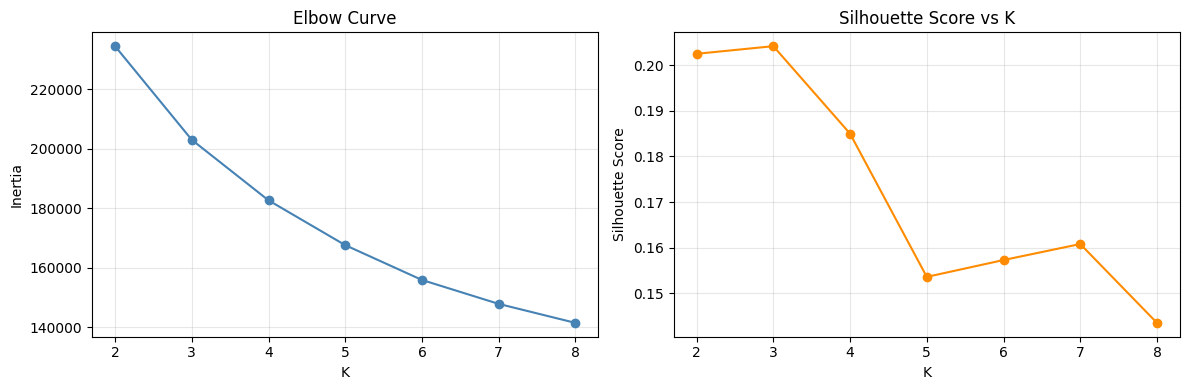


Auto-selected K = 3  (Silhouette = 0.2042)

FINAL K-MEANS (K=3)
  Silhouette Score : 0.2042
  Davies-Bouldin   : 1.5912

Cluster sizes:
km_cluster
0    20571
1     9571
2    19858

CLUSTER PROFILES
            study_hours_day  sleep_hours_day  screen_time_day  study_efficiency  habit_stability  extra_hours
km_cluster                                                                                                   
0                     4.995            7.189            2.329             0.591            0.730        1.492
1                     5.063            6.458            3.674             0.461            0.642        5.558
2                     5.431            5.729            2.533             0.442            0.551        1.418

Cluster labels:
  Cluster 0 → Balanced
  Cluster 1 → Balanced
  Cluster 2 → Balanced

DBSCAN (5k sample)
  Clusters found : 1
  Noise points   : 516 (10.3%)
  DBSCAN found <2 clusters — K-Means wins.

MODEL COMPARISON
Algorithm              Clusters 

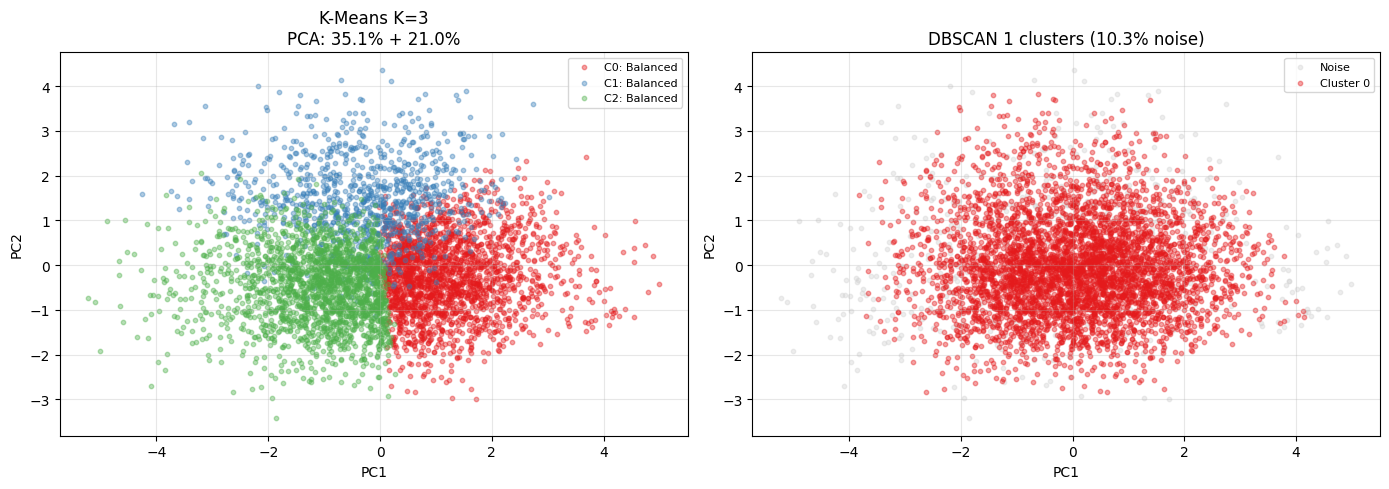


Merged back into df. Shape: (50000, 49)

Model 2 complete.


In [ ]:
# ============================================================
# ML MODEL 2 — RERUN WITH FOCUSED FEATURES
# Replace your Model 2 cell with this
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster       import KMeans, DBSCAN
from sklearn.metrics       import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from google.colab          import files

# ── 1. FOCUSED FEATURE SET ───────────────────────────────────
# Only 6 core behavioural axes — minimal redundancy
# Temporal features excluded: they're derived from these 6
# and inflate distance calculations without adding structure
TIME_FEATURES = [
    "study_hours_day",    # effort quantity
    "sleep_hours_day",    # recovery
    "screen_time_day",    # distraction
    "study_efficiency",   # effort quality
    "habit_stability",    # consistency
    "extra_hours",        # extracurricular load
]

snap = df.dropna(subset=TIME_FEATURES).copy().reset_index(drop=True)
print(f"Rows for clustering : {len(snap)}")
print(f"Features used       : {len(TIME_FEATURES)} → {TIME_FEATURES}")

# ── 2. SCALE ─────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(snap[TIME_FEATURES])
print("Scaling done.")

# ── 3. FIND OPTIMAL K ────────────────────────────────────────
print("\n" + "="*55)
print("FINDING OPTIMAL K (K=2 to 8)")
print("="*55)

np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample   = X_scaled[sample_idx]

K_RANGE    = range(2, 9)
inertias   = []
sil_scores = []
db_scores  = []

for k in K_RANGE:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    labs = km.fit_predict(X_scaled)
    sil  = silhouette_score(X_sample, labs[sample_idx])
    db   = davies_bouldin_score(X_sample, labs[sample_idx])
    inertias.append(km.inertia_)
    sil_scores.append(sil)
    db_scores.append(db)
    print(f"  K={k}  Silhouette={sil:.4f}  Davies-Bouldin={db:.4f}")

# ── 4. PLOTS ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_RANGE), inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Curve"); axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia"); axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_RANGE), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs K"); axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score"); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("model2_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 5. AUTO-SELECT BEST K ─────────────────────────────────────
best_k = list(K_RANGE)[sil_scores.index(max(sil_scores))]
print(f"\nAuto-selected K = {best_k}  (Silhouette = {max(sil_scores):.4f})")

# ── 6. FINAL K-MEANS ─────────────────────────────────────────
print("\n" + "="*55)
print(f"FINAL K-MEANS (K={best_k})")
print("="*55)

kmeans_final       = KMeans(n_clusters=best_k, random_state=42, n_init=20)
snap["km_cluster"] = kmeans_final.fit_predict(X_scaled)

km_sil = silhouette_score(X_sample, snap["km_cluster"].values[sample_idx])
km_db  = davies_bouldin_score(X_sample, snap["km_cluster"].values[sample_idx])
print(f"  Silhouette Score : {km_sil:.4f}")
print(f"  Davies-Bouldin   : {km_db:.4f}")
print(f"\nCluster sizes:")
print(snap["km_cluster"].value_counts().sort_index().to_string())

# ── 7. CLUSTER PROFILES ───────────────────────────────────────
print("\n" + "="*55)
print("CLUSTER PROFILES")
print("="*55)
profile = snap.groupby("km_cluster")[TIME_FEATURES].mean().round(3)
print(profile.to_string())

# ── 8. SMART AUTO-LABELLING ───────────────────────────────────
# Rank clusters on each axis, assign label from dominant trait
def label_cluster(row):
    study = row["study_hours_day"]
    eff   = row["study_efficiency"]
    sleep = row["sleep_hours_day"]
    screen= row["screen_time_day"]
    stab  = row["habit_stability"]
    extra = row["extra_hours"]

    scores = {
        "High Effort"       : study,
        "Efficient Studier" : eff * 10,
        "Sleep Deprived"    : (9 - sleep),
        "High Screen Time"  : screen,
        "Balanced"          : stab * 10,
        "Extracurricular"   : extra,
    }
    return max(scores, key=scores.get)

cluster_labels           = {i: label_cluster(profile.loc[i]) for i in profile.index}
snap["km_cluster_label"] = snap["km_cluster"].map(cluster_labels)

print("\nCluster labels:")
for k, v in cluster_labels.items():
    print(f"  Cluster {k} → {v}")

# ── 9. DBSCAN ────────────────────────────────────────────────
print("\n" + "="*55)
print("DBSCAN (5k sample)")
print("="*55)

dbscan  = DBSCAN(eps=1.2, min_samples=20, n_jobs=-1)
db_labs = dbscan.fit_predict(X_sample)

n_clusters_db = len(set(db_labs)) - (1 if -1 in db_labs else 0)
n_noise       = (db_labs == -1).sum()
noise_pct     = n_noise / len(X_sample) * 100
print(f"  Clusters found : {n_clusters_db}")
print(f"  Noise points   : {n_noise} ({noise_pct:.1f}%)")

if n_clusters_db >= 2:
    mask   = db_labs != -1
    db_sil = silhouette_score(X_sample[mask], db_labs[mask])
    db_db  = davies_bouldin_score(X_sample[mask], db_labs[mask])
    print(f"  Silhouette     : {db_sil:.4f}")
    print(f"  Davies-Bouldin : {db_db:.4f}")
else:
    db_sil = 0
    print("  DBSCAN found <2 clusters — K-Means wins.")

# ── 10. COMPARISON ───────────────────────────────────────────
print("\n" + "="*55)
print("MODEL COMPARISON")
print("="*55)
print(f"{'Algorithm':<20} {'Clusters':>10} {'Silhouette':>12} {'D-B Score':>12}")
print("-"*55)
print(f"{'K-Means (full)':<20} {best_k:>10} {km_sil:>12.4f} {km_db:>12.4f}")
if n_clusters_db >= 2:
    print(f"{'DBSCAN (5k)':<20} {n_clusters_db:>10} {db_sil:>12.4f} {db_db:>12.4f}")
best_algo = "K-Means"
if n_clusters_db >= 2 and db_sil > km_sil + 0.05:
    best_algo = "DBSCAN"
print(f"\nBest algorithm: {best_algo}")

# ── 11. PCA VISUALISATION ────────────────────────────────────
pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_sample)
var_exp = pca.explained_variance_ratio_
colors  = plt.cm.Set1.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
km_sample_labs = snap["km_cluster"].values[sample_idx]
for c in sorted(set(km_sample_labs)):
    mask = km_sample_labs == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f"C{c}: {cluster_labels[c]}",
                    alpha=0.4, s=10, color=colors[c % len(colors)])
axes[0].set_title(f"K-Means K={best_k}\nPCA: {var_exp[0]*100:.1f}% + {var_exp[1]*100:.1f}%")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

for c in sorted(set(db_labs)):
    mask  = db_labs == c
    label = "Noise" if c == -1 else f"Cluster {c}"
    col   = "lightgrey" if c == -1 else colors[c % len(colors)]
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=label, alpha=0.4, s=10, color=col)
axes[1].set_title(f"DBSCAN {n_clusters_db} clusters ({noise_pct:.1f}% noise)")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("model2_cluster_viz.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 12. MERGE BACK ───────────────────────────────────────────
# Drop old cluster columns if they exist from previous run
df.drop(columns=[c for c in ["km_cluster","km_cluster_label"] if c in df.columns],
        inplace=True)
df = df.merge(
    snap[["student_id", "week", "km_cluster", "km_cluster_label"]],
    on=["student_id", "week"], how="left"
)
print(f"\nMerged back into df. Shape: {df.shape}")

# ── 13. SAVE & DOWNLOAD ──────────────────────────────────────
joblib.dump(kmeans_final,   "model2_kmeans.pkl")
joblib.dump(scaler,         "model2_scaler.pkl")
joblib.dump(TIME_FEATURES,  "model2_features.pkl")
joblib.dump(cluster_labels, "model2_cluster_labels.pkl")

# for fname in ["model2_kmeans.pkl", "model2_scaler.pkl",
#               "model2_features.pkl", "model2_cluster_labels.pkl",
#               "model2_elbow_silhouette.png", "model2_cluster_viz.png"]:
#     files.download(fname)

print("\nModel 2 complete.")

In [ ]:
# ── CLUSTER LABEL FIX — run as new cell ──────────────────────

# Manually assign based on profile analysis
cluster_labels = {
    0: "Balanced & Efficient",
    1: "Extracurricular Focused",
    2: "Overworked & Struggling"
}

# Update in df
df.drop(columns=["km_cluster_label"], errors="ignore", inplace=True)
df["km_cluster_label"] = df["km_cluster"].map(cluster_labels)

# Verify
print("Cluster label distribution:")
print(df["km_cluster_label"].value_counts().to_string())
print()
print("Verification — mean profiles per label:")
print(df.groupby("km_cluster_label")[
    ["study_hours_day","sleep_hours_day","screen_time_day",
     "study_efficiency","habit_stability","extra_hours"]
].mean().round(3).to_string())

# Update saved artifact
# import joblib
# joblib.dump(cluster_labels, "model2_cluster_labels.pkl")
# from google.colab import files
# files.download("model2_cluster_labels.pkl")
# print("\nCluster labels fixed and saved.")

Cluster label distribution:
km_cluster_label
Balanced & Efficient       20571
Overworked & Struggling    19858
Extracurricular Focused     9571

Verification — mean profiles per label:
                         study_hours_day  sleep_hours_day  screen_time_day  study_efficiency  habit_stability  extra_hours
km_cluster_label                                                                                                          
Balanced & Efficient               4.995            7.189            2.329             0.591            0.730        1.492
Extracurricular Focused            5.063            6.458            3.674             0.461            0.642        5.558
Overworked & Struggling            5.431            5.729            2.533             0.442            0.551        1.418


Total features used : 40
Target classes      : ['High', 'Low', 'Medium']

Class distribution:
pressure_label
Medium    27866
Low       13692
High       8442

Train rows : 40000  (2000 students)
Test rows  : 10000  (500 students)
Imputation done.

CROSS-VALIDATION (5-fold, stratified)

[Random Forest] 5-Fold CV
  Accuracy    : 0.8264
  F1 Macro    : 0.8183
  F1 Weighted : 0.8265

[Gradient Boosting] 5-Fold CV
  Accuracy    : 0.8623
  F1 Macro    : 0.8515
  F1 Weighted : 0.8616

FINAL TRAINING ON FULL TRAIN SET
Both models trained.

HELD-OUT TEST EVALUATION

[Random Forest]
  Accuracy    : 0.8259
  F1 Macro    : 0.8176
  F1 Weighted : 0.8261

  Classification Report:
              precision    recall  f1-score   support

        High       0.78      0.83      0.80      1680
         Low       0.80      0.81      0.81      2745
      Medium       0.85      0.83      0.84      5575

    accuracy                           0.83     10000
   macro avg       0.81      0.82      0.82     10000


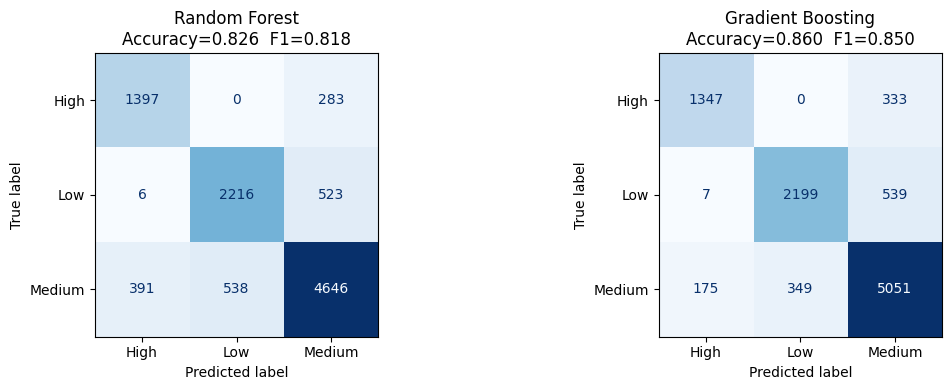

Confusion matrix saved.

TOP 20 FEATURE IMPORTANCES — Gradient Boosting
deadline_density            0.2972
sleep_hours_day             0.1915
pressure_score_delta1       0.1891
deadline_count              0.1336
pressure_roll3              0.0528
pressure_acceleration       0.0389
screen_time_day             0.0271
prev_deadline_density       0.0172
km_cluster_enc              0.0165
study_efficiency            0.0075
sleep_hours_day_slope3      0.0055
study_hours_day             0.0052
habit_stability             0.0040
performance_score_slope3    0.0022
sleep_hours_day_delta1      0.0016
study_hours_day_slope3      0.0013
attendance_pct              0.0012
deadline_density_roll3      0.0008
late_night_ratio            0.0006
week                        0.0006

Temporal features in top 20 : 8
  pressure_score_delta1  (0.1891)
  pressure_roll3  (0.0528)
  pressure_acceleration  (0.0389)
  sleep_hours_day_slope3  (0.0055)
  performance_score_slope3  (0.0022)
  sleep_hours_day_delta1  (0

In [ ]:
# ============================================================
# ML MODEL 3 — Trend-Based Risk Detection (Classification)
# Paste in a NEW cell, directly below Model 2 cell.
# Requires: df, pd, np, files, joblib already in session
# Target: pressure_label (Low / Medium / High)
# This model's primary signal = temporal/trend features
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection  import cross_validate, StratifiedKFold
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      ConfusionMatrixDisplay, f1_score)
from sklearn.preprocessing    import LabelEncoder
from sklearn.impute            import SimpleImputer
from google.colab             import files

# ── 1. FEATURE DEFINITION ────────────────────────────────────
# Model 3's job: detect RISING RISK from trends
# Temporal features are PRIMARY here — not secondary like in Model 1

TARGET = "pressure_label"

EXCLUDE = [
    "student_id",
    "pressure_label",         # target
    "pressure_score",         # direct numeric form of target — exclude to avoid leakage
    "performance_score",      # outcome, not input
    "goal_alignment",         # outcome
    "alignment_label",        # outcome
    "is_edge_case",           # meta
    "edge_case_type",         # meta
    "pressure_momentum_label",# categorical — encoded below
    "km_cluster_label",       # categorical — encoded below
    "goal",                   # categorical — encoded below
]

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

# Encode categoricals
le_goal      = joblib.load("model1_le_goal.pkl")     # reuse from Model 1
le_momentum  = joblib.load("model1_le_momentum.pkl") # reuse from Model 1
le_cluster   = LabelEncoder()

df["goal_enc"]              = le_goal.transform(df["goal"])
df["pressure_momentum_enc"] = le_momentum.transform(df["pressure_momentum_label"])
df["km_cluster_enc"]        = le_cluster.fit_transform(
                                  df["km_cluster_label"].fillna("Unknown"))

# Remove string cols, add encoded versions
FEATURE_COLS = [c for c in FEATURE_COLS
                if c not in ["goal", "pressure_momentum_label", "km_cluster_label",
                             "km_cluster"]]
FEATURE_COLS += ["goal_enc", "pressure_momentum_enc", "km_cluster_enc"]

# Encode target
le_target  = LabelEncoder()
df["pressure_label_enc"] = le_target.fit_transform(df[TARGET])
CLASS_NAMES = le_target.classes_   # ['High', 'Low', 'Medium']

print(f"Total features used : {len(FEATURE_COLS)}")
print(f"Target classes      : {list(CLASS_NAMES)}")
print(f"\nClass distribution:")
print(df[TARGET].value_counts().to_string())

# ── 2. TRAIN / TEST SPLIT BY STUDENT ID ──────────────────────
np.random.seed(42)
all_students  = df["student_id"].unique()
n_test        = int(len(all_students) * 0.20)
test_students = np.random.choice(all_students, size=n_test, replace=False)

train_df = df[~df["student_id"].isin(test_students)].copy()
test_df  = df[ df["student_id"].isin(test_students)].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df["pressure_label_enc"]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df["pressure_label_enc"]

print(f"\nTrain rows : {len(X_train)}  ({train_df.student_id.nunique()} students)")
print(f"Test rows  : {len(X_test)}  ({test_df.student_id.nunique()} students)")

# ── 3. IMPUTE ─────────────────────────────────────────────────
imputer3 = SimpleImputer(strategy="median")
X_train  = imputer3.fit_transform(X_train)
X_test   = imputer3.transform(X_test)
print("Imputation done.")

# ── 4. MODELS ─────────────────────────────────────────────────
rf3 = RandomForestClassifier(
    n_estimators    = 100,
    max_depth       = 15,
    min_samples_leaf= 4,
    class_weight    = "balanced",   # handles Medium class dominance (56%)
    n_jobs          = -1,
    random_state    = 42
)

gb3 = GradientBoostingClassifier(
    n_estimators    = 100,
    learning_rate   = 0.1,
    max_depth       = 4,
    min_samples_leaf= 4,
    random_state    = 42
)

# ── 5. CROSS-VALIDATION ───────────────────────────────────────
print("\n" + "="*55)
print("CROSS-VALIDATION (5-fold, stratified)")
print("="*55)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [("Random Forest", rf3), ("Gradient Boosting", gb3)]:
    cv = cross_validate(
        model, X_train, y_train, cv=skf,
        scoring=["accuracy", "f1_macro", "f1_weighted"],
        n_jobs=-1
    )
    print(f"\n[{name}] 5-Fold CV")
    print(f"  Accuracy    : {cv['test_accuracy'].mean():.4f}")
    print(f"  F1 Macro    : {cv['test_f1_macro'].mean():.4f}")
    print(f"  F1 Weighted : {cv['test_f1_weighted'].mean():.4f}")

# ── 6. FINAL TRAINING ─────────────────────────────────────────
print("\n" + "="*55)
print("FINAL TRAINING ON FULL TRAIN SET")
print("="*55)
rf3.fit(X_train, y_train)
gb3.fit(X_train, y_train)
print("Both models trained.")

# ── 7. HELD-OUT TEST EVALUATION ──────────────────────────────
print("\n" + "="*55)
print("HELD-OUT TEST EVALUATION")
print("="*55)

results = {}
for name, model in [("Random Forest", rf3), ("Gradient Boosting", gb3)]:
    preds = model.predict(X_test)
    acc   = (preds == y_test.values).mean()
    f1m   = f1_score(y_test, preds, average="macro")
    f1w   = f1_score(y_test, preds, average="weighted")
    results[name] = {"acc": acc, "f1m": f1m, "f1w": f1w,
                     "model": model, "preds": preds}
    print(f"\n[{name}]")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  F1 Macro    : {f1m:.4f}")
    print(f"  F1 Weighted : {f1w:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, preds, target_names=CLASS_NAMES))

# ── 8. PICK BEST MODEL ────────────────────────────────────────
print("="*55)
print("MODEL COMPARISON")
print("="*55)
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>12}")
print("-"*55)
for name, r in results.items():
    print(f"{name:<25} {r['acc']:>10.4f} {r['f1m']:>10.4f} {r['f1w']:>12.4f}")

best_name  = max(results, key=lambda n: results[n]["f1m"])
best_model = results[best_name]["model"]
best_preds = results[best_name]["preds"]
print(f"\nBest model: {best_name} (higher F1 Macro)")

# ── 9. CONFUSION MATRIX ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, r) in zip(axes, results.items()):
    cm  = confusion_matrix(y_test, r["preds"])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nAccuracy={r['acc']:.3f}  F1={r['f1m']:.3f}")

plt.tight_layout()
plt.savefig("model3_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved.")

# ── 10. FEATURE IMPORTANCES ──────────────────────────────────
print("\n" + "="*55)
print(f"TOP 20 FEATURE IMPORTANCES — {best_name}")
print("="*55)
importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)
print(importances.head(20).round(4).to_string())

# Highlight temporal features in top 20
temporal_suffixes = ("_roll3","_slope3","_vol3","_delta1",
                     "_acceleration","_momentum_enc")
top20 = importances.head(20)
temporal_in_top20 = [f for f in top20.index
                     if any(f.endswith(s) for s in temporal_suffixes)]
print(f"\nTemporal features in top 20 : {len(temporal_in_top20)}")
for f in temporal_in_top20:
    print(f"  {f}  ({importances[f]:.4f})")

# ── 11. SAVE ARTIFACTS ────────────────────────────────────────
joblib.dump(best_model,   "model3_risk_detector.pkl")
joblib.dump(imputer3,     "model3_imputer.pkl")
joblib.dump(le_cluster,   "model3_le_cluster.pkl")
joblib.dump(le_target,    "model3_le_target.pkl")
joblib.dump(FEATURE_COLS, "model3_feature_cols.pkl")

print("\nSaved artifacts:")
print("  model3_risk_detector.pkl")
print("  model3_imputer.pkl")
print("  model3_le_cluster.pkl")
print("  model3_le_target.pkl")
print("  model3_feature_cols.pkl")

# for fname in ["model3_risk_detector.pkl", "model3_imputer.pkl",
#               "model3_le_cluster.pkl",    "model3_le_target.pkl",
#               "model3_feature_cols.pkl",  "model3_confusion_matrix.png"]:
#     files.download(fname)

print("\nModel 3 complete.")